### Objective
0. Run after neur4.ipynb
1. Does population encode a stimulus axis? PCA & Regression. No.  
2. Does pairwise neural similarity depend systematically on condition? RDMs. Kinda.  
3. Same, but for on-manifold similarity. TBD.  
4. Is neural similarity based on absolute or relative positional proximity?  
5. Is context-dependent stimulus class decodable? Decoding accuracy. No, but absolute class is..  

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, glob, os
import scipy.stats as stats, scipy.io as sio
from statsmodels.stats.multitest import fdrcorrection
from sklearn.decomposition import PCA


plot settings

In [2]:
# sns.set(context='paper')

# keep text editable in svg
plt.rcParams['svg.fonttype'] = 'none'

import matplotlib as mpl
# push ticks inward
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
# remove top and right splines
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# %matplotlib widget
%matplotlib inline


variables & functions

In [3]:
psychopy_df = pd.read_csv('../../results/psychopy/all_subjs.csv')
# trials col first
psychopy_df = psychopy_df[['trial_key', *psychopy_df.columns.difference(['trial_key'], sort=False)]]
patients = psychopy_df['subj'].unique().tolist()
for patient in [1.1, 1.11, 1.111, 1.1111, 9, 11]: patients.remove(patient)
conditions = ['curv_comp', 'baseline', 'flat_comp']

from neur_utils import get_contrast_in_epoch, get_pt_epoch_spike_data, get_pt_metadata

print(f'neural patients: {patients}')
print(f'conditions: {conditions}')

neural patients: [12.0, 18.0, 21.0, 22.0]
conditions: ['curv_comp', 'baseline', 'flat_comp']


### 1. Does population encode a stimulus axis? PCA & Regression.

In [4]:
epoch = 'stim'
normalize_FRs = True

# per patient, compute trial by neuron FR, by avging across bins
pt_data = {}
for patient in patients:
    pt_psychopy_df, _, pt_num_neurs = get_pt_metadata(psychopy_df, patient, verbose=False)
    _, _, pt_epoch_FRs, _ = get_pt_epoch_spike_data(patient, epoch, verbose=False)

    if normalize_FRs:
        _, _, pt_baseline_FRs, _ = get_pt_epoch_spike_data(patient, 'baseline', verbose=False)
        pt_epoch_FRs = pt_epoch_FRs - pt_baseline_FRs.mean(axis=(0, 2), keepdims=True)

    meanFRs = pt_epoch_FRs.mean(axis=2)  # trials x neurons
    pt_data[patient] = {'psychopy': pt_psychopy_df, 'meanFRs': meanFRs, 'n_neurs': pt_num_neurs}


# per patient and condition,compute stim by neuron FR
cond_pt_means = {}
for cond in conditions:
    cond_pt_means[cond] = {}
    for patient in patients:
        pt_psychopy_df = pt_data[patient]['psychopy']
        cond2mask      = (pt_psychopy_df['condition'] == cond).values
        cond2stims     = pt_psychopy_df.loc[cond2mask, 'true_stim'].round(2).values
        cond_meanFRs   = pt_data[patient]['meanFRs'][cond2mask]
        df_tmp = pd.DataFrame(cond_meanFRs)
        df_tmp['true_stim'] = cond2stims
        cond_pt_means[cond][patient] = df_tmp.groupby('true_stim').mean()  # (n_unique_pos, n_neurs)

# stack neurons across patients → PCA sees one shared population geometry
stim_by_neur, cond2stimss = {}, {} # (stim, neurs), (stim vals,)
for cond in conditions:
    all_stims = sorted(cond_pt_means[cond][patients[0]].index)
    FR_stimXneur = np.hstack([cond_pt_means[cond][pt].loc[all_stims].values for pt in patients])
    stim_by_neur[cond]   = FR_stimXneur
    cond2stimss[cond] = np.array(all_stims)
    print(f'{cond}: {len(all_stims)} unique true_stim values, matrix {FR_stimXneur.shape}')

total_neurs = FR_stimXneur.shape[1]
print(f'\ntotal neurons across patients: {total_neurs}')

curv_comp: 15 unique true_stim values, matrix (15, 57)
baseline: 20 unique true_stim values, matrix (20, 57)
flat_comp: 15 unique true_stim values, matrix (15, 57)

total neurons across patients: 57


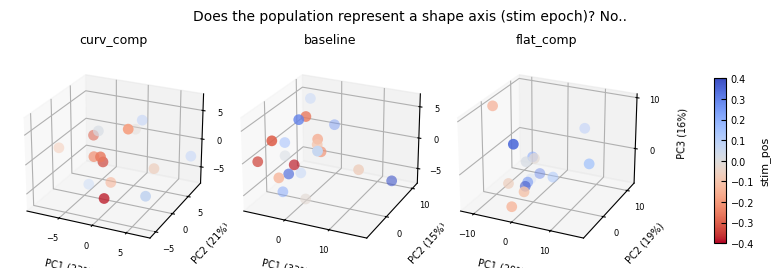

In [5]:
# does each boundary context have its own shape axis?
# fit PCA separately so each condition gets its own coordinate frame

view_elev, view_azim = 24, -65

plt.close('all')
fig = plt.figure(figsize=(8, 3))
for i, cond in enumerate(conditions, 1):
    ax = fig.add_subplot(1, 3, i, projection='3d')
    pca    = PCA(n_components=3)
    coords = pca.fit_transform(stim_by_neur[cond])
    ev     = pca.explained_variance_ratio_
    sc     = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                        c=cond2stimss[cond], cmap='coolwarm_r', vmin=-0.4, vmax=0.4,
                        s=60, linewidths=0)
    ax.set_title(cond, fontsize=9)
    ax.set_xlabel(f'PC1 ({ev[0]*100:.0f}%)', fontsize=7, labelpad=1)
    ax.set_ylabel(f'PC2 ({ev[1]*100:.0f}%)', fontsize=7, labelpad=1)
    ax.set_zlabel(f'PC3 ({ev[2]*100:.0f}%)', fontsize=7, labelpad=1)
    ax.tick_params(labelsize=6, pad=0)
    ax.locator_params(nbins=3)
    ax.view_init(elev=view_elev, azim=view_azim)

cbar_ax = fig.add_axes([0.88, 0.2, 0.015, 0.55])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('stim_pos', fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.suptitle(f'Does the population represent a shape axis ({epoch} epoch)? No..', fontsize=10)
plt.subplots_adjust(left=0.0, right=0.8, wspace=0.05)
plt.show()

condition     R² (LOO-CV)
curv_comp           0.149
baseline            0.013
flat_comp          -0.277


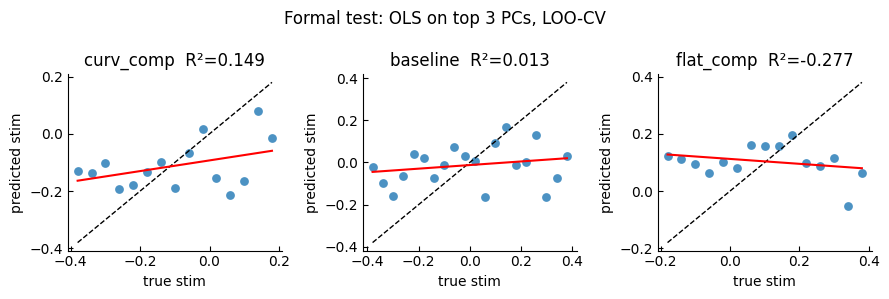

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score

# does the population linearly encode stim_pos? OLS on top 3 PCs (avoids p>>n)
n_pcs = 3
loo = LeaveOneOut()

fig, axs = plt.subplots(1, 3, figsize=(9, 3))
print(f"{'condition':<12} {'R² (LOO-CV)':>12}")
for ax, cond in zip(axs, conditions):
    X, y = stim_by_neur[cond], cond2stimss[cond]
    y_pred = np.empty_like(y)
    for train, test in loo.split(X):
        X_train, y_train = X[train], y[train]
        X_test,  y_test  = X[test],  y[test]
        # fit PCA on train only to avoid leakage, project both
        pca = PCA(n_components=n_pcs)
        X_train_pca = pca.fit_transform(X_train)
        X_test_pca  = pca.transform(X_test)
        y_pred[test] = LinearRegression().fit(X_train_pca, y_train).predict(X_test_pca)
    r2 = r2_score(y, y_pred)
    print(f"{cond:<12} {r2:>12.3f}")

    ax.scatter(y, y_pred, s=40, alpha=0.8, linewidths=0)
    lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='identity')
    m, b = np.polyfit(y, y_pred, 1)
    x_line = np.linspace(y.min(), y.max(), 100)
    ax.plot(x_line, m * x_line + b, 'r-', linewidth=1.5, label='best fit')
    ax.set(xlabel='true stim', ylabel='predicted stim', title=f'{cond}  R²={r2:.3f}')

plt.suptitle(f'Formal test: OLS on top {n_pcs} PCs, LOO-CV')
plt.tight_layout()
plt.show()

### 2. Does pairwise neural similarity track positional similarity? RSA and spearman.

In [7]:
# # what stim positions were sampled per condition, and where does the boundary fall?
# # explains the asymmetric coverage in curv/flat that causes black rows/cols in the DSM

# fig, axs = plt.subplots(3, 1, figsize=(3, 9))
# for ax, cond in zip(axs, conditions):
#     sub = psychopy_df[psychopy_df['condition'] == cond]
#     stims    = sub['true_stim'].round(2)
#     pos_vals = sorted(stims.unique())
#     counts   = stims.value_counts().sort_index()

#     ax.bar(pos_vals, counts.values, width=0.03, color='steelblue', alpha=0.7)
#     for div in sorted(sub['true_boundary'].unique()):
#         ax.axvline(div, color='r', linewidth=1.5, linestyle='--')
#     ax.set_xlim(-0.45, 0.45)
#     ax.set_xlabel('true_stim')
#     ax.set_ylabel('# trials')
#     ax.set_title(cond)
#     ax.set_xticks(pos_vals)
#     ax.set_xticklabels([f'{v:.2f}' for v in pos_vals], rotation=90, fontsize=5)

# plt.suptitle('Stimulus sampling per context')
# plt.tight_layout()
# plt.show()

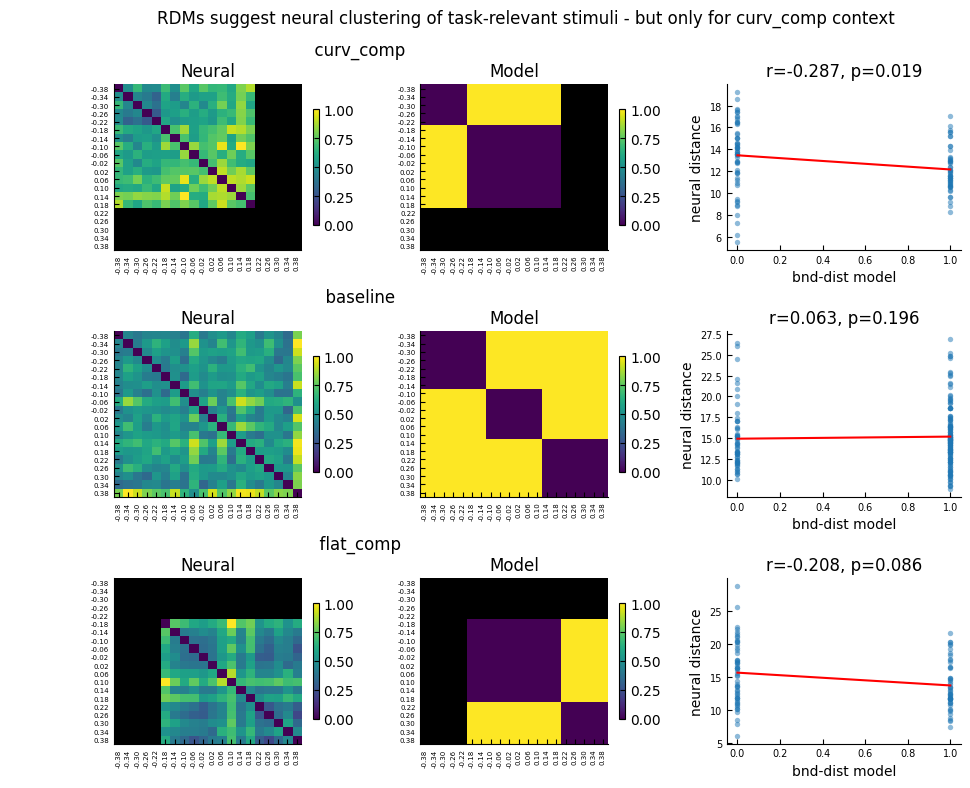

In [8]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

def minmax_0_1(mat):
    # scale matrix to [0,1] for better visualization; ignores NaNs in curv/flat contexts
    mat_min = np.nanmin(mat)
    mat_max = np.nanmax(mat)
    return (mat - mat_min) / (mat_max - mat_min)

# rows/cols = all possible true_stim positions in this experiment
# cells where a condition didn't sample that position are blacked out
n_perms = 1000
rng = np.random.default_rng(0)

near_bnd_halfwidth = 0.1  # tunable: baseline "near-boundary" zone = boundary ± this value

# boundary position per condition (needed for stimulus model)
cond_boundary = {
    cond: psychopy_df[psychopy_df['condition'] == cond]['true_boundary'].mean()
    for cond in conditions
}

# Shared RDM plotting template. Each condition's smaller RDM is pasted into this grid.
plot_stim_axis = sorted(set().union(*[set(cond2stimss[cond]) for cond in conditions]))
n_plot_stims = len(plot_stim_axis)

cmap_rdm = plt.cm.viridis.copy()
cmap_rdm.set_bad('black') # for stims missing from a particular context
tick_labels = [f'{s:.2f}' for s in plot_stim_axis]

fig, axs = plt.subplots(3, 3, figsize=(9, 8))

for row, cond in enumerate(conditions):
    cond_neural_patterns = stim_by_neur[cond]
    cond_stims = cond2stimss[cond]

    # This condition's stims are a contiguous block in the plot template.
    # Conditions with shifted stim grids get pasted farther down/right.
    rdm_template_start = plot_stim_axis.index(cond_stims[0])
    rdm_template_stop = rdm_template_start + len(cond_stims)
    rdm_template_slice = slice(rdm_template_start, rdm_template_stop)
    assert np.allclose(plot_stim_axis[rdm_template_slice], cond_stims), f'{cond} stims are not a contiguous RDM template block'

    # # 1. Model: dissim(i,j) = stim_dist_to_bnd[i] + stim_dist_to_bnd[j]
    # # both near boundary → low; both far → high
    # cond_stim_dist_to_bnd = np.abs(cond_stims - cond_boundary[cond])
    # cond_model_rdm = cond_stim_dist_to_bnd[:, None] + cond_stim_dist_to_bnd[None, :] # pairwise sum of distances to boundary

    # 1. Model: block-categorical
    # curv/flat → 2 clusters (same class = similar, across boundary = dissimilar)
    # baseline  → 3 clusters (far-class-0 | near-boundary zone | far-class-1)
    if cond == 'baseline':
        cluster = np.where(
            cond_stims < cond_boundary[cond] - near_bnd_halfwidth, 0,
            np.where(cond_stims > cond_boundary[cond] + near_bnd_halfwidth, 2, 1)
        )
        cond_model_rdm = (cluster[:, None] != cluster[None, :]).astype(float)
    else:
        cond_classes = (cond_stims >= cond_boundary[cond]).astype(float)
        cond_model_rdm = (cond_classes[:, None] != cond_classes[None, :]).astype(float)

    # 2. Neural: condition RDM before it gets pasted into the plot template
    cond_neural_rdm = squareform(pdist(cond_neural_patterns)) # pairwise neural distances for sampled stims only

    # now, initialize full-sized matrices; curv/flat conditions will have some NaNs in these
    neural_rdm_template = np.full((n_plot_stims, n_plot_stims), np.nan)
    model_rdm_template  = np.full((n_plot_stims, n_plot_stims), np.nan)
    neural_rdm_template[rdm_template_slice, rdm_template_slice] = cond_neural_rdm
    model_rdm_template[rdm_template_slice, rdm_template_slice] = cond_model_rdm

    # RSA: Spearman correlation between neural and model RDM upper triangles
    # permutation test: shuffle stim positions to get a null distribution
    upper_triangle_idx = np.triu_indices(len(cond_stims), k=1)
    neural_pair_dists = cond_neural_rdm[upper_triangle_idx]
    model_pair_dists  = cond_model_rdm[upper_triangle_idx]
    observed_r, _ = spearmanr(neural_pair_dists, model_pair_dists)
    permuted_r = np.empty(n_perms)
    for k in range(n_perms):
        # # perm_stim_dist_to_bnd = np.abs(rng.permutation(cond_stims) - cond_boundary[cond])
        # # permuted_r[k] = spearmanr(neural_pair_dists, (perm_stim_dist_to_bnd[:, None] + perm_stim_dist_to_bnd[None, :])[upper_triangle_idx])[0]
        perm_stims = rng.permutation(cond_stims)
        if cond == 'baseline':
            perm_cluster = np.where(
                perm_stims < cond_boundary[cond] - near_bnd_halfwidth, 0,
                np.where(perm_stims > cond_boundary[cond] + near_bnd_halfwidth, 2, 1)
            )
            perm_model = (perm_cluster[:, None] != perm_cluster[None, :]).astype(float)
        else:
            perm_classes = (perm_stims >= cond_boundary[cond]).astype(float)
            perm_model = (perm_classes[:, None] != perm_classes[None, :]).astype(float)
        permuted_r[k] = spearmanr(neural_pair_dists, perm_model[upper_triangle_idx])[0]
    perm_p = (np.abs(permuted_r) >= np.abs(observed_r)).mean()

    # neural RDM
    ax = axs[row, 0]
    im = ax.imshow(minmax_0_1(neural_rdm_template), cmap=cmap_rdm, aspect='auto', interpolation='none')
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set(title=f'                                                          {cond}\nNeural')
    ax.set_xticks(range(n_plot_stims)); ax.set_xticklabels(tick_labels, rotation=90, fontsize=5)
    ax.set_yticks(range(n_plot_stims)); ax.set_yticklabels(tick_labels, fontsize=5)

    # stimulus model RDM (same mask)
    ax = axs[row, 1]
    im = ax.imshow(minmax_0_1(model_rdm_template), cmap=cmap_rdm, aspect='auto', interpolation='none')
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set(title='Model')
    ax.set_xticks(range(n_plot_stims)); ax.set_xticklabels(tick_labels, rotation=90, fontsize=5)
    ax.set_yticks(range(n_plot_stims)); ax.set_yticklabels(tick_labels, fontsize=5)

    # scatter with line of best fit
    ax = axs[row, 2]
    ax.scatter(model_pair_dists, neural_pair_dists, s=15, alpha=0.5, linewidths=0)
    m, b = np.polyfit(model_pair_dists, neural_pair_dists, 1)
    x_line = np.linspace(model_pair_dists.min(), model_pair_dists.max(), 100)
    ax.plot(x_line, m * x_line + b, 'r-', linewidth=1.5)
    ax.set(xlabel='bnd-dist model', ylabel='neural distance', title=f'r={observed_r:.3f}, p={perm_p:.3f}')
    ax.tick_params(labelsize=7)

plt.suptitle(f'RDMs suggest neural clustering of task-relevant stimuli - but only for curv_comp context')
plt.tight_layout()
plt.show()

### 3. Same, but for on-manifold similarity.

### 4. Is neural similarity based on absolute or relative positional proximity?  

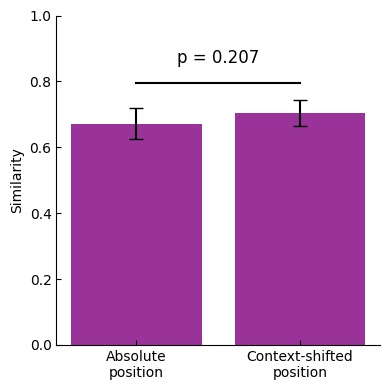

In [9]:
from itertools import combinations
from scipy.stats import ttest_rel

# --- Context-shift alignment MSEs: absolute vs boundary-relative neural patterns ---
cond_pairs = list(combinations(conditions, 2))
neural_align_rows = []

for patient in patients:
    for cond_a, cond_b in cond_pairs:
        boundary_a = cond_boundary[cond_a]
        boundary_b = cond_boundary[cond_b]

        a_abs_pos = cond_pt_means[cond_a][patient].index.to_numpy().round(3)
        b_abs_pos = cond_pt_means[cond_b][patient].index.to_numpy().round(3)
        a_rel_pos = (a_abs_pos - boundary_a).round(3)
        b_rel_pos = (b_abs_pos - boundary_b).round(3)

        a_abs_df = pd.DataFrame(cond_pt_means[cond_a][patient].values, index=a_abs_pos)
        b_abs_df = pd.DataFrame(cond_pt_means[cond_b][patient].values, index=b_abs_pos)
        a_rel_df = pd.DataFrame(cond_pt_means[cond_a][patient].values, index=a_rel_pos)
        b_rel_df = pd.DataFrame(cond_pt_means[cond_b][patient].values, index=b_rel_pos)

        # absolute: compare neural patterns at same true_stim
        shared_abs = np.intersect1d(a_abs_df.index.values, b_abs_df.index.values)
        abs_mse = np.nan
        if len(shared_abs) > 0:
            abs_diff = a_abs_df.loc[shared_abs].values - b_abs_df.loc[shared_abs].values
            abs_mse = np.mean(abs_diff ** 2)

        # boundary-relative: compare neural patterns at same stim_boundary_aligned
        shared_rel = np.intersect1d(a_rel_df.index.values, b_rel_df.index.values)
        rel_mse = np.nan
        if len(shared_rel) > 0:
            rel_diff = a_rel_df.loc[shared_rel].values - b_rel_df.loc[shared_rel].values
            rel_mse = np.mean(rel_diff ** 2)

        neural_align_rows.append({
            'patient': patient,
            'cond_pair': f'{cond_a} vs {cond_b}',
            'abs_mse': abs_mse,
            'rel_mse': rel_mse,
            'n_abs_overlap': len(shared_abs),
            'n_rel_overlap': len(shared_rel),
        })

neural_align_df = pd.DataFrame(neural_align_rows).dropna(subset=['abs_mse', 'rel_mse'])
all_abs_MSEs = neural_align_df['abs_mse'].values
all_rel_MSEs = neural_align_df['rel_mse'].values

t_stat, p_val = ttest_rel(all_abs_MSEs, all_rel_MSEs)

fig, axs = plt.subplots(1, 1, figsize=(4, 4))
axs = [axs]  # flatten for consistent indexing
ax = 0

alpha = .1  # adjust as needed for your scale
abs_similarity = np.exp(-alpha * all_abs_MSEs)
rel_similarity = np.exp(-alpha * all_rel_MSEs)

means = [abs_similarity.mean(), rel_similarity.mean()]
sems = [abs_similarity.std() / np.sqrt(len(abs_similarity)),
        rel_similarity.std() / np.sqrt(len(rel_similarity))]

bars = axs[ax].bar([0, 1], means, yerr=sems, capsize=5, color=['purple', 'purple'], alpha=0.8)
axs[ax].set(xticks=[0, 1], xticklabels=['Absolute\nposition', 'Context-shifted\nposition'], ylabel='Similarity')
axs[ax].grid(False)
# axs[ax].set_title(f'Neural patterns are aligned to context — {epoch} epoch')

# Draw only horizontal line connecting bar tops
bar_tops = [means[0] + sems[0], means[1] + sems[1]]
line_y = max(bar_tops) + 0.05
axs[ax].plot([0, 1], [line_y, line_y], color='black', linewidth=1.5)

# Place p just above the line, within plot area
axs[ax].text(0.5, line_y + 0.05, f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)

# Increase ylim if needed to fit p value
axs[ax].set_ylim(0, line_y + 0.005)
axs[ax].set_ylim(0, 1)

plt.tight_layout()
plt.show()


### 5. Is context-dependent stimulus class decodable? Decoding accuracy & chance.  

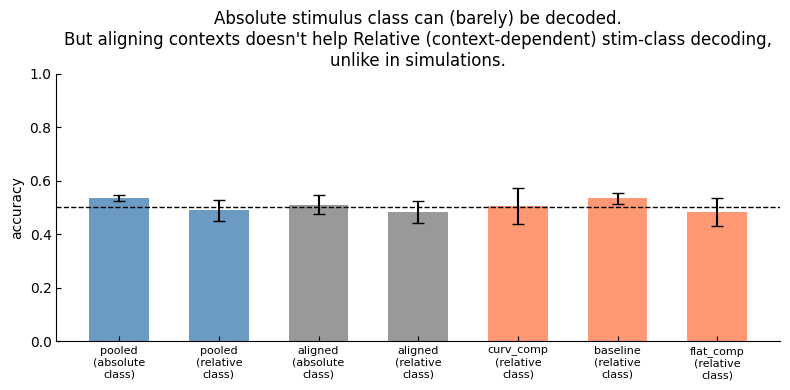

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

clf = LogisticRegression(penalty=None, max_iter=1000)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

def demean_condition_activity(X, conditions_by_trial):
    X_demeaned = X.copy()
    for cond in np.unique(conditions_by_trial):
        idx = conditions_by_trial == cond
        X_demeaned[idx] = X[idx] - X[idx].mean(axis=0)
    return X_demeaned

def decode_across_patients(get_y, cond_filter=None, demean_conditions=False):
    accs = []
    for patient in patients:
        pt_psychopy_df = pt_data[patient]['psychopy']
        X = pt_data[patient]['meanFRs']
        y = get_y(pt_psychopy_df)
        if demean_conditions:
            X = demean_condition_activity(X, pt_psychopy_df['condition'].values)
        if cond_filter is not None:
            mask = pt_psychopy_df['condition'] == cond_filter
            X, y = X[mask], y[mask]
        accs.append(cross_val_score(clf, X, y, cv=cv, scoring='accuracy').mean())
    return np.array(accs)

# absolute_class: is true_stim above 0 regardless of boundary?
# relative_class: is true_stim above the boundary? (stim_boundary_aligned > 0 is consistent across subjects)
absolute_class = lambda df: (df['true_stim'] > 0).astype(int).values
relative_class = lambda df: (df['stim_boundary_aligned'] > 0).astype(int).values

# 7 bars: pooled absolute/relative, de-meaned pooled absolute/relative, then per-condition relative only
bar_specs = [
    ('pooled',     'absolute\nclass', absolute_class, None, False),
    ('pooled',     'relative\nclass', relative_class, None, False),
    ('aligned',     'absolute\nclass', absolute_class, None, True),
    ('aligned',     'relative\nclass', relative_class, None, True),
    ('curv_comp',  'relative\nclass', relative_class, 'curv_comp', False),
    ('baseline',   'relative\nclass', relative_class, 'baseline', False),
    ('flat_comp',  'relative\nclass', relative_class, 'flat_comp', False),
]
labels    = [f'{scope}\n({target})' for scope, target, _, _, _ in bar_specs]
bar_data  = [decode_across_patients(get_y, cond, demean) for _, _, get_y, cond, demean in bar_specs]
colors    = ['steelblue', 'steelblue', 'grey', 'grey', 'coral', 'coral', 'coral']

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(bar_specs))
for i, (accs, color) in enumerate(zip(bar_data, colors)):
    ax.bar(x[i], accs.mean(), yerr=accs.std(), color=color, alpha=0.8, capsize=4, width=0.6)

ax.axhline(0.5, color='k', linestyle='--', linewidth=1, label='chance (50%)')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('accuracy')
ax.set_ylim(0, 1)
ax.set_title(f"Absolute stimulus class can (barely) be decoded.\nBut aligning contexts doesn't help Relative (context-dependent) stim-class decoding,\nunlike in simulations.")
plt.tight_layout()
plt.show()

In [11]:
# # do conditions separate in a shared geometry?
# # fit one PC space so differences show up as displacement, not just a rotation of coordinates
# view_elev, view_azim = 24, -65

# X_all     = np.vstack([cond_matrices[c] for c in conditions])
# pca_joint = PCA(n_components=3).fit(X_all)
# ev_j      = pca_joint.explained_variance_ratio_

# markers = {'baseline': 'o', 'curv_comp': '^', 'flat_comp': 's'}
# fig = plt.figure(figsize=(6, 5))
# ax  = fig.add_subplot(111, projection='3d')
# for cond in conditions:
#     coords = pca_joint.transform(cond_matrices[cond])
#     sc = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
#                     c=cond_pos_values[cond], cmap='coolwarm', vmin=-0.4, vmax=0.4,
#                     s=60, marker=markers[cond], linewidths=0, label=cond)

# plt.colorbar(sc, ax=ax, label='stim_pos')
# ax.legend(title='condition', loc='best', frameon=False)
# ax.set(title=f'Representations separate by context?',
#        xlabel=f'PC1 ({ev_j[0]*100:.1f}%)', ylabel=f'PC2 ({ev_j[1]*100:.1f}%)',
#        zlabel=f'PC3 ({ev_j[2]*100:.1f}%)')
# ax.view_init(elev=view_elev, azim=view_azim)
# plt.tight_layout()
# plt.show()